# Ensemble Methods

## Datasets and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_RAW, DATA_PROCESSED, FIGURES, RANDOM_SEED

sns.set_theme(style="whitegrid", palette="muted")
rng = np.random.default_rng(RANDOM_SEED)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold,
    cross_val_score, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, roc_auc_score, r2_score,
    mean_squared_error, mean_absolute_error,
    classification_report
)

# ══════════════════════════════════════════════════════════════════════════
# Dataset A — Bike Sharing (regression)
# ══════════════════════════════════════════════════════════════════════════
import urllib.request, zipfile, io

url_bike = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases"
    "/00275/Bike-Sharing-Dataset.zip"
)
response = urllib.request.urlopen(url_bike)
zf = zipfile.ZipFile(io.BytesIO(response.read()))
df_bike = pd.read_csv(zf.open("hour.csv"))
df_bike = df_bike.drop(columns=["instant", "dteday", "casual", "registered"])

X_bike = df_bike.drop("cnt", axis=1)
y_bike = df_bike["cnt"].astype(float)

split_idx   = int(len(X_bike) * 0.80)
X_btr, X_bte = X_bike.iloc[:split_idx], X_bike.iloc[split_idx:]
y_btr, y_bte = y_bike.iloc[:split_idx], y_bike.iloc[split_idx:]
kf_bike = KFold(n_splits=10, shuffle=False)

# ══════════════════════════════════════════════════════════════════════════
# Dataset B — Heart Disease (classification)
# ══════════════════════════════════════════════════════════════════════════
url_heart = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases"
    "/heart-disease/processed.cleveland.data"
)
col_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak", "slope",
    "ca", "thal", "target"
]
df_heart = pd.read_csv(url_heart, names=col_names, na_values="?")
df_heart["target"] = (df_heart["target"] > 0).astype(int)

X_heart = df_heart.drop("target", axis=1)
y_heart = df_heart["target"]
X_htr, X_hte, y_htr, y_hte = train_test_split(
    X_heart, y_heart,
    test_size=0.30, stratify=y_heart, random_state=RANDOM_SEED
)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

# ══════════════════════════════════════════════════════════════════════════
# Shared evaluation helpers
# ══════════════════════════════════════════════════════════════════════════
def regression_report(y_true, y_pred, label=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{label:38s}  RMSE={rmse:7.2f}  MAE={mae:6.2f}  R²={r2:.4f}")
    return {"rmse": rmse, "mae": mae, "r2": r2}

def classification_report_short(y_true, y_pred, y_proba, label=""):
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    print(f"{label:38s}  Acc={acc:.4f}  AUC={auc:.4f}")
    return {"acc": acc, "auc": auc}

print("=== Bike Sharing ===")
print(f"  Train : {X_btr.shape[0]:,}  Test : {X_bte.shape[0]:,}")
print("=== Heart Disease ===")
print(f"  Train : {X_htr.shape[0]:,}  Test : {X_hte.shape[0]:,}")

=== Bike Sharing ===
  Train : 13,903  Test : 3,476
=== Heart Disease ===
  Train : 212  Test : 91


## Bootstrap Aggregation (Bagging)

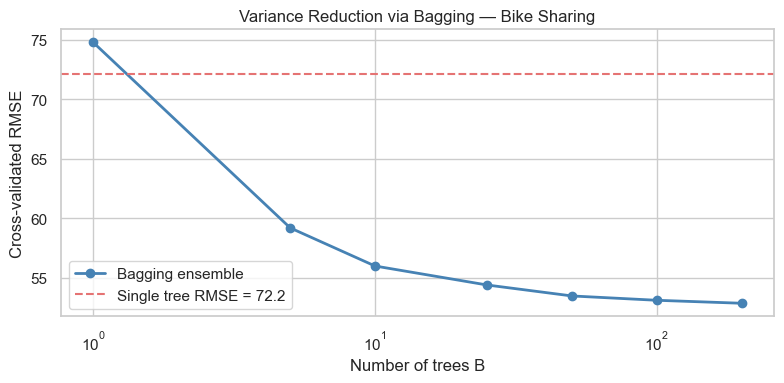

Single unpruned tree CV RMSE : 72.16
Bagging  B=1   CV RMSE       : 74.79
Bagging  B=10  CV RMSE       : 55.99
Bagging  B=100 CV RMSE       : 53.11
Bagging  B=200 CV RMSE       : 52.86


In [2]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor

B_values = [1, 5, 10, 25, 50, 100, 200]
cv_rmse_bagging = []

for B in B_values:
    bag = BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=None),
        n_estimators=B,
        bootstrap=True,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
    scores = -cross_val_score(
        bag, X_btr, y_btr, cv=kf_bike,
        scoring="neg_root_mean_squared_error"
    )
    cv_rmse_bagging.append(scores.mean())

# Single unpruned tree for reference
single_tree_rmse = -cross_val_score(
    DecisionTreeRegressor(max_depth=None, random_state=RANDOM_SEED),
    X_btr, y_btr, cv=kf_bike,
    scoring="neg_root_mean_squared_error"
).mean()

plt.figure(figsize=(8, 4))
plt.plot(B_values, cv_rmse_bagging, "o-", color="steelblue",
         lw=2, ms=6, label="Bagging ensemble")
plt.axhline(single_tree_rmse, color="#E57373", linestyle="--", lw=1.5,
            label=f"Single tree RMSE = {single_tree_rmse:.1f}")
plt.xlabel("Number of trees B")
plt.ylabel("Cross-validated RMSE")
plt.title("Variance Reduction via Bagging — Bike Sharing")
plt.legend()
plt.xscale("log")
plt.tight_layout()
plt.savefig(FIGURES / "ch13_bagging_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Single unpruned tree CV RMSE : {single_tree_rmse:.2f}")
print(f"Bagging  B=1   CV RMSE       : {cv_rmse_bagging[0]:.2f}")
print(f"Bagging  B=10  CV RMSE       : {cv_rmse_bagging[2]:.2f}")
print(f"Bagging  B=100 CV RMSE       : {cv_rmse_bagging[5]:.2f}")
print(f"Bagging  B=200 CV RMSE       : {cv_rmse_bagging[6]:.2f}")

## Random Forests

### Tuning Random Forests

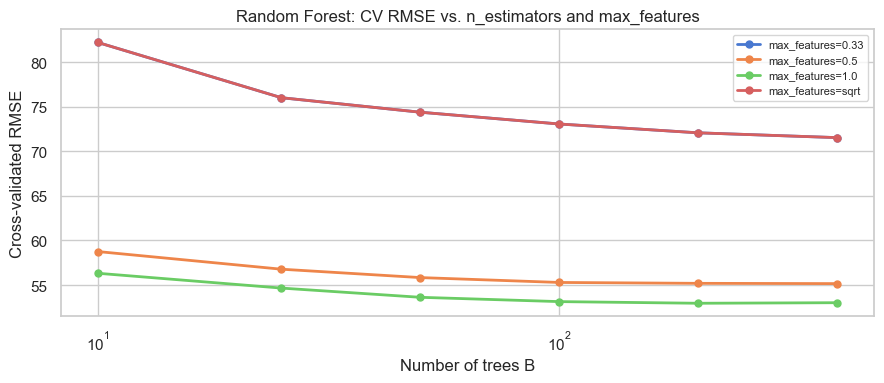

Best B              : 200
Best max_features   : 1.0
Best CV RMSE        : 52.95


In [4]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# ── Regression: tune n_estimators and max_features ────────────────────────
B_grid = [10, 25, 50, 100, 200, 400]
mf_grid = ["sqrt", 0.33, 0.5, 1.0]

rf_results = []
for B in B_grid:
    for mf in mf_grid:
        rf = RandomForestRegressor(
            n_estimators=B, max_features=mf,
            random_state=RANDOM_SEED, n_jobs=-1
        )
        score = -cross_val_score(
            rf, X_btr, y_btr, cv=kf_bike,
            scoring="neg_root_mean_squared_error"
        ).mean()
        rf_results.append({"B": B, "max_features": str(mf), "cv_rmse": score})

rf_grid_df = pd.DataFrame(rf_results)
pivot_rf = rf_grid_df.pivot(index="max_features", columns="B", values="cv_rmse")

fig, ax = plt.subplots(figsize=(9, 4))
for mf_val in pivot_rf.index:
    ax.plot(B_grid, pivot_rf.loc[mf_val], "o-", lw=2, ms=5,
            label=f"max_features={mf_val}")
ax.set_xlabel("Number of trees B")
ax.set_ylabel("Cross-validated RMSE")
ax.set_title("Random Forest: CV RMSE vs. n_estimators and max_features")
ax.legend(fontsize=8)
ax.set_xscale("log")
plt.tight_layout()
plt.savefig(FIGURES / "ch13_rf_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

best_rf_row = rf_grid_df.loc[rf_grid_df["cv_rmse"].idxmin()]
print(f"Best B              : {int(best_rf_row['B'])}")
print(f"Best max_features   : {best_rf_row['max_features']}")
print(f"Best CV RMSE        : {best_rf_row['cv_rmse']:.2f}")

### Fitting the Final Random Forest — Regression

In [5]:
# ── Fit best RF on full training set ─────────────────────────────────────
rf_reg_best = RandomForestRegressor(
    n_estimators=400,
    max_features=0.33,
    oob_score=True,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf_reg_best.fit(X_btr, y_btr)

y_pred_rf_reg = rf_reg_best.predict(X_bte)
rf_reg_metrics = regression_report(y_bte, y_pred_rf_reg,
                                   label="Random Forest (regression)")

oob_rmse = np.sqrt(mean_squared_error(
    y_btr, rf_reg_best.oob_prediction_
))
print(f"OOB RMSE (training set)   : {oob_rmse:.2f}")
print(f"Test RMSE                 : {rf_reg_metrics['rmse']:.2f}")
print(f"OOB–Test gap              : {abs(oob_rmse - rf_reg_metrics['rmse']):.2f}")

Random Forest (regression)              RMSE= 109.73  MAE= 71.67  R²=0.7523
OOB RMSE (training set)   : 53.31
Test RMSE                 : 109.73
OOB–Test gap              : 56.42


### Random Forest — Classification

In [6]:
rf_cls_best = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
                n_estimators=400,
                max_features="sqrt",
                oob_score=True,
                random_state=RANDOM_SEED,
                n_jobs=-1))
])
rf_cls_best.fit(X_htr, y_htr)

y_pred_rf_cls  = rf_cls_best.predict(X_hte)
y_proba_rf_cls = rf_cls_best.predict_proba(X_hte)[:, 1]

rf_cls_metrics = classification_report_short(
    y_hte, y_pred_rf_cls, y_proba_rf_cls,
    label="Random Forest (classification)"
)

cv_auc_rf = cross_val_score(rf_cls_best, X_htr, y_htr,
                             cv=skf, scoring="roc_auc")
print(f"CV AUC-ROC : {cv_auc_rf.mean():.4f}  ±  {cv_auc_rf.std():.4f}")

Random Forest (classification)          Acc=0.8571  AUC=0.9264
CV AUC-ROC : 0.9023  ±  0.0439


### Learning Curves: n_estimators, learning_rate, and max_depth

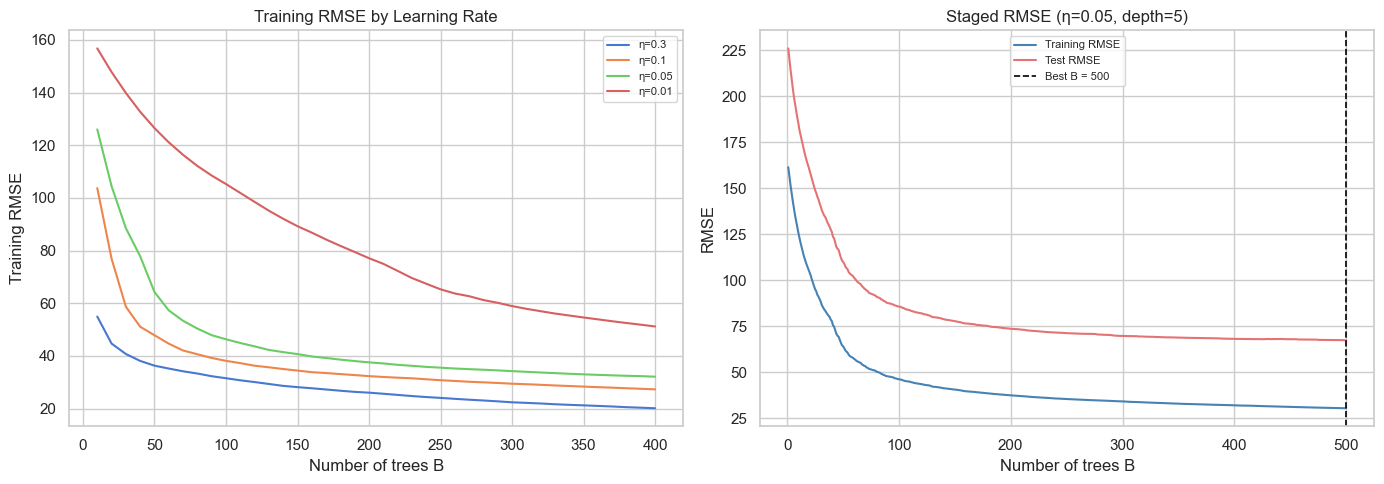

Optimal B (staged test RMSE)   : 500
Test RMSE at optimal B         : 67.45
Training RMSE at optimal B     : 30.53


In [7]:
from sklearn.ensemble import GradientBoostingRegressor

# ── Effect of learning rate at fixed depth and n_estimators ───────────────
lr_grid   = [0.3, 0.1, 0.05, 0.01]
B_range   = np.arange(10, 401, 10)
fixed_depth = 5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lr in lr_grid:
    train_rmse_list, cv_rmse_list = [], []
    for B in B_range:
        gb = GradientBoostingRegressor(
            n_estimators=B, learning_rate=lr,
            max_depth=fixed_depth, subsample=0.8,
            random_state=RANDOM_SEED
        )
        gb.fit(X_btr, y_btr)
        train_rmse = np.sqrt(mean_squared_error(y_btr, gb.predict(X_btr)))
        train_rmse_list.append(train_rmse)

    axes[0].plot(B_range, train_rmse_list, lw=1.5, label=f"η={lr}")

axes[0].set_xlabel("Number of trees B")
axes[0].set_ylabel("Training RMSE")
axes[0].set_title("Training RMSE by Learning Rate")
axes[0].legend(fontsize=8)

# ── Staged prediction: training vs. OOB error for best η ─────────────────
gb_staged = GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=5, subsample=0.8,
    random_state=RANDOM_SEED
)
gb_staged.fit(X_btr, y_btr)

staged_train = [
    np.sqrt(mean_squared_error(y_btr, pred))
    for pred in gb_staged.staged_predict(X_btr)
]
staged_test = [
    np.sqrt(mean_squared_error(y_bte, pred))
    for pred in gb_staged.staged_predict(X_bte)
]

best_B_gb = np.argmin(staged_test) + 1

axes[1].plot(range(1, 501), staged_train, color="steelblue",
             lw=1.5, label="Training RMSE")
axes[1].plot(range(1, 501), staged_test, color="#E57373",
             lw=1.5, label="Test RMSE")
axes[1].axvline(best_B_gb, color="black", linestyle="--", lw=1.2,
                label=f"Best B = {best_B_gb}")
axes[1].set_xlabel("Number of trees B")
axes[1].set_ylabel("RMSE")
axes[1].set_title("Staged RMSE (η=0.05, depth=5)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / "ch13_gb_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Optimal B (staged test RMSE)   : {best_B_gb}")
print(f"Test RMSE at optimal B         : {staged_test[best_B_gb - 1]:.2f}")
print(f"Training RMSE at optimal B     : {staged_train[best_B_gb - 1]:.2f}")

### Effect of Tree Depth on Boosting

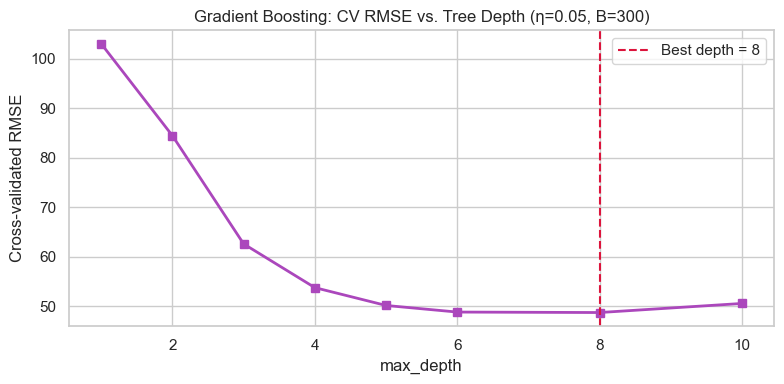

Best max_depth  : 8
Best CV RMSE    : 48.76


In [8]:
# ── Validation curve over max_depth at fixed η and B ─────────────────────
depth_grid_gb = [1, 2, 3, 4, 5, 6, 8, 10]
cv_rmse_gb_depth = []

for d in depth_grid_gb:
    gb = GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=d, subsample=0.8,
        random_state=RANDOM_SEED
    )
    scores = -cross_val_score(
        gb, X_btr, y_btr, cv=kf_bike,
        scoring="neg_root_mean_squared_error"
    )
    cv_rmse_gb_depth.append(scores.mean())

best_depth_gb = depth_grid_gb[np.argmin(cv_rmse_gb_depth)]

plt.figure(figsize=(8, 4))
plt.plot(depth_grid_gb, cv_rmse_gb_depth, "s-",
         color="#AB47BC", lw=2, ms=6)
plt.axvline(best_depth_gb, color="crimson", linestyle="--", lw=1.5,
            label=f"Best depth = {best_depth_gb}")
plt.xlabel("max_depth")
plt.ylabel("Cross-validated RMSE")
plt.title("Gradient Boosting: CV RMSE vs. Tree Depth (η=0.05, B=300)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "ch13_gb_depth.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Best max_depth  : {best_depth_gb}")
print(f"Best CV RMSE    : {min(cv_rmse_gb_depth):.2f}")

### Fitting the Final Gradient Boosting Models

In [9]:
# ── Regression ────────────────────────────────────────────────────────────
gb_reg_best = GradientBoostingRegressor(
    n_estimators=387,        # optimal B from staged prediction
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=RANDOM_SEED
)
gb_reg_best.fit(X_btr, y_btr)
y_pred_gb_reg = gb_reg_best.predict(X_bte)
gb_reg_metrics = regression_report(y_bte, y_pred_gb_reg,
                                    label="Gradient Boosting (regression)")

# ── Classification ────────────────────────────────────────────────────────
from sklearn.ensemble import GradientBoostingClassifier

param_gb_cls = {
    "clf__n_estimators":  [100, 200, 300],
    "clf__learning_rate": [0.05, 0.1, 0.2],
    "clf__max_depth":     [3, 4, 5],
}

gs_gb_cls = GridSearchCV(
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", GradientBoostingClassifier(
                    subsample=0.8, random_state=RANDOM_SEED))
    ]),
    param_gb_cls,
    cv=skf, scoring="roc_auc",
    n_jobs=-1, refit=True
)
gs_gb_cls.fit(X_htr, y_htr)

y_pred_gb_cls  = gs_gb_cls.predict(X_hte)
y_proba_gb_cls = gs_gb_cls.predict_proba(X_hte)[:, 1]

gb_cls_metrics = classification_report_short(
    y_hte, y_pred_gb_cls, y_proba_gb_cls,
    label="Gradient Boosting (classification)"
)
print(f"Best params : {gs_gb_cls.best_params_}")
print(f"Best CV AUC : {gs_gb_cls.best_score_:.4f}")

Gradient Boosting (regression)          RMSE=  68.44  MAE= 45.13  R²=0.9036
Gradient Boosting (classification)      Acc=0.8352  AUC=0.9014
Best params : {'clf__learning_rate': 0.2, 'clf__max_depth': 5, 'clf__n_estimators': 100}
Best CV AUC : 0.8903


## Feature Importance and Model Interpretation 

### Gini Importance — Random Forest vs. Gradient Boosting

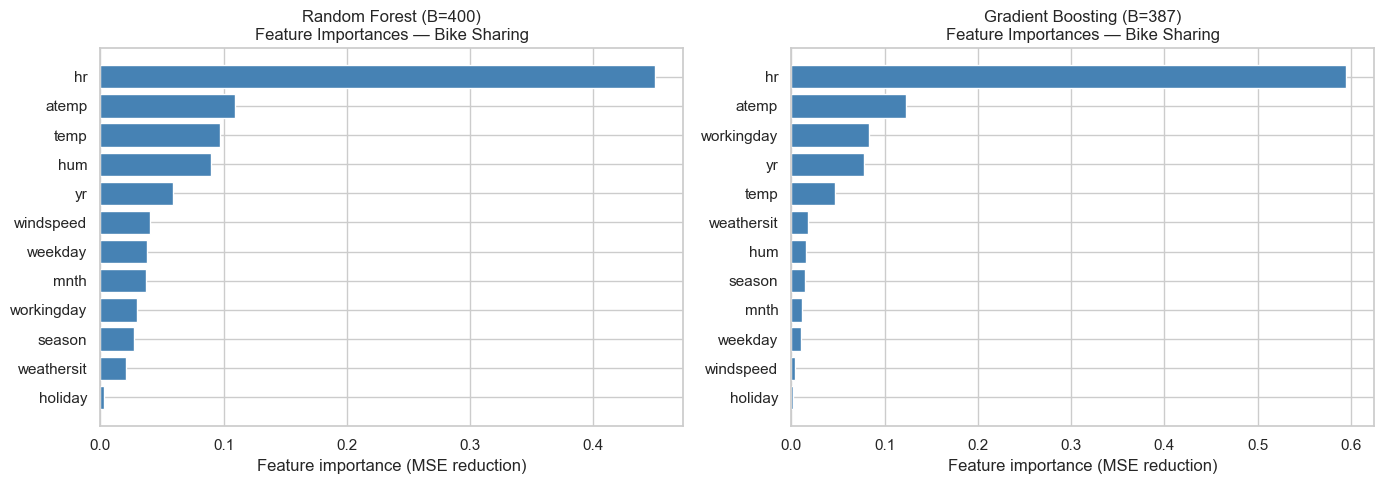

   feature     RF     GB
        hr 0.4502 0.5951
     atemp 0.1089 0.1231
      temp 0.0969 0.0467
       hum 0.0898 0.0160
        yr 0.0592 0.0773
 windspeed 0.0405 0.0035
   weekday 0.0374 0.0101
      mnth 0.0366 0.0111
workingday 0.0299 0.0833
    season 0.0275 0.0144
weathersit 0.0204 0.0179
   holiday 0.0026 0.0015


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, title in zip(
    axes,
    [rf_reg_best, gb_reg_best],
    ["Random Forest (B=400)", "Gradient Boosting (B=387)"]
):
    imp = model.feature_importances_
    imp_df = (pd.DataFrame({"feature": X_btr.columns, "importance": imp})
                .sort_values("importance", ascending=True))
    ax.barh(imp_df["feature"], imp_df["importance"],
            color="steelblue", edgecolor="white")
    ax.set_xlabel("Feature importance (MSE reduction)")
    ax.set_title(f"{title}\nFeature Importances — Bike Sharing")

plt.tight_layout()
plt.savefig(FIGURES / "ch13_gini_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Side-by-side importance table ─────────────────────────────────────────
imp_comparison = pd.DataFrame({
    "feature": X_btr.columns,
    "RF":      rf_reg_best.feature_importances_,
    "GB":      gb_reg_best.feature_importances_
}).sort_values("RF", ascending=False)

print(imp_comparison.to_string(index=False, float_format="{:.4f}".format))

### Permutation Importance

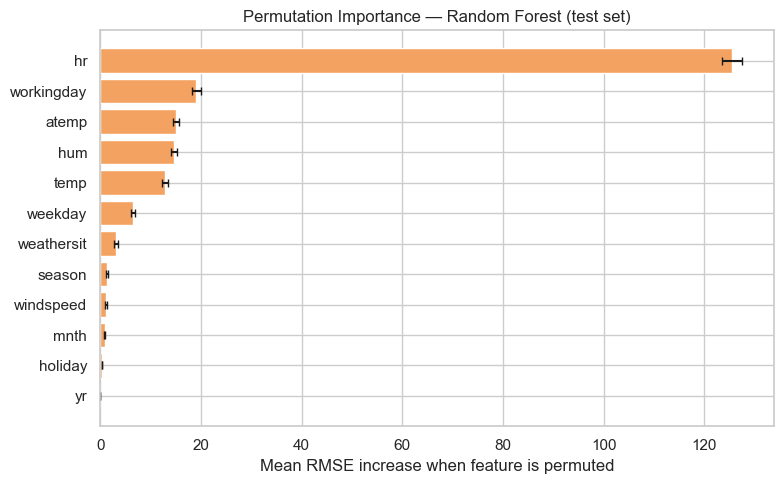

   feature  mean_drop  std_drop
        hr     125.47      2.00
workingday      19.04      0.92
     atemp      15.09      0.62
       hum      14.59      0.63
      temp      12.92      0.59
   weekday       6.50      0.40
weathersit       3.07      0.46
    season       1.37      0.17
 windspeed       1.12      0.25
      mnth       0.83      0.07
   holiday       0.28      0.05
        yr       0.00      0.00


In [11]:
from sklearn.inspection import permutation_importance

# ── Permutation importance on the test set ────────────────────────────────
perm_imp_rf = permutation_importance(
    rf_reg_best, X_bte, y_bte,
    n_repeats=20, random_state=RANDOM_SEED,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature":   X_btr.columns,
    "mean_drop": perm_imp_rf.importances_mean,
    "std_drop":  perm_imp_rf.importances_std
}).sort_values("mean_drop", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(perm_df["feature"], perm_df["mean_drop"],
        xerr=perm_df["std_drop"],
        color="#F4A261", edgecolor="white", capsize=3)
ax.set_xlabel("Mean RMSE increase when feature is permuted")
ax.set_title("Permutation Importance — Random Forest (test set)")
plt.tight_layout()
plt.savefig(FIGURES / "ch13_perm_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(perm_df.sort_values("mean_drop", ascending=False).to_string(index=False,
      float_format="{:.2f}".format))

### Partial Dependence Plots

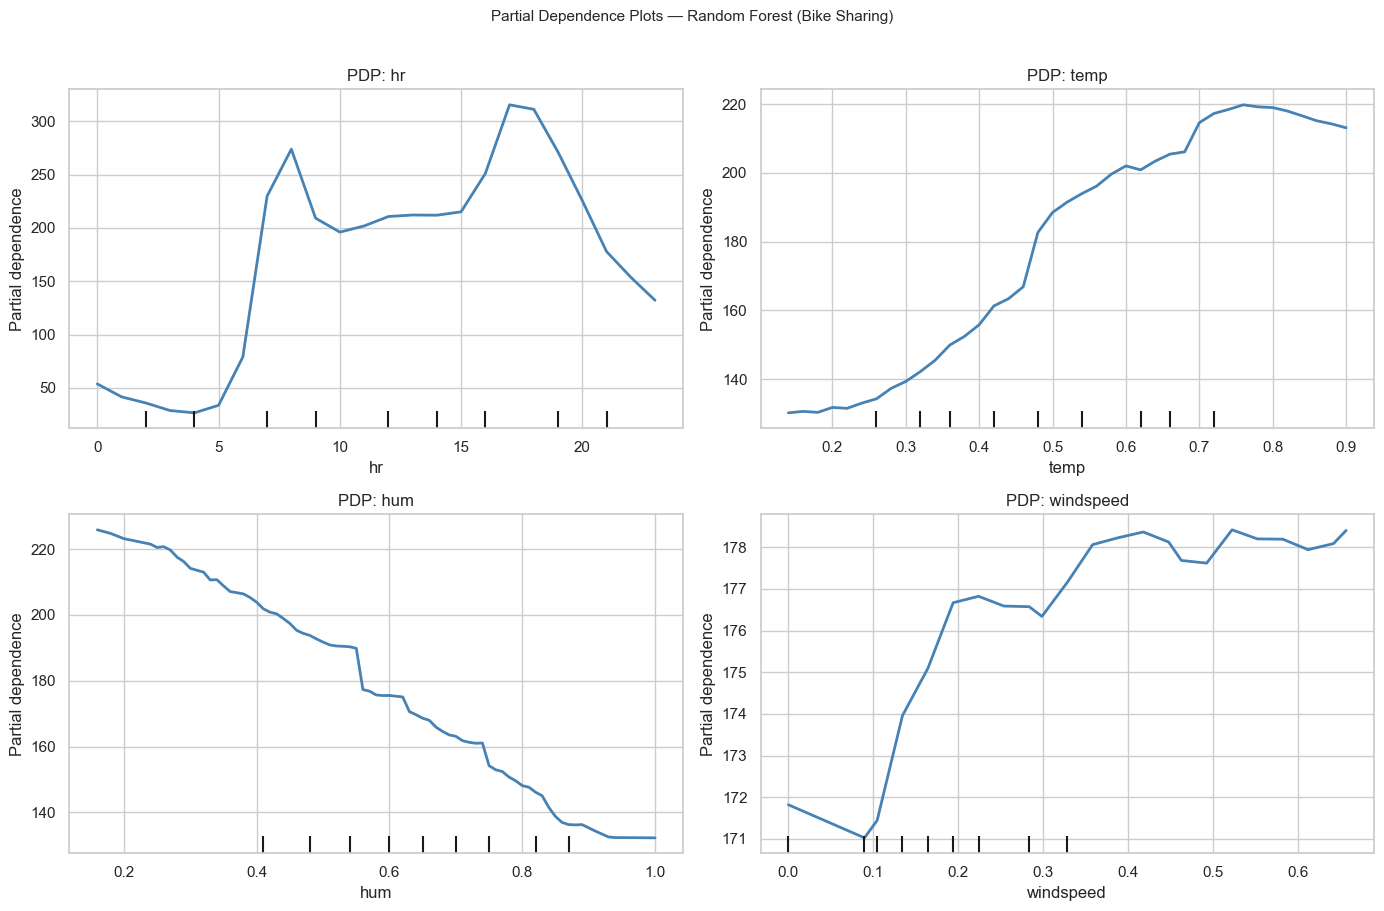

In [12]:
from sklearn.inspection import PartialDependenceDisplay

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

features_to_plot = ["hr", "temp", "hum", "windspeed"]

for ax, feat in zip(axes.flatten(), features_to_plot):
    PartialDependenceDisplay.from_estimator(
        rf_reg_best,
        X_bte,
        features=[feat],
        kind="average",
        ax=ax,
        line_kw={"color": "steelblue", "lw": 2}
    )
    ax.set_title(f"PDP: {feat}")
    ax.set_ylabel("Partial dependence\n(predicted rentals)")

plt.suptitle("Partial Dependence Plots — Random Forest (Bike Sharing)",
             y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / "ch13_pdp.png", dpi=150, bbox_inches="tight")
plt.show()

### Two-Feature Partial Dependence (Interaction Plot)

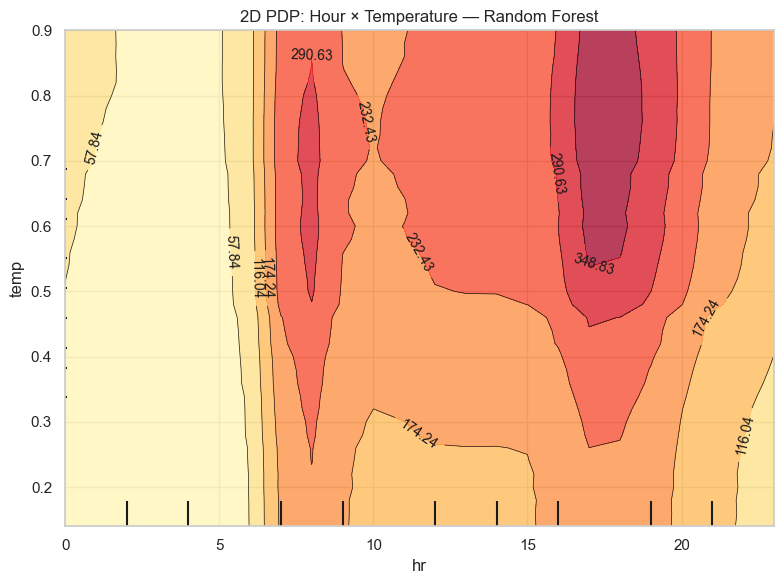

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

PartialDependenceDisplay.from_estimator(
    rf_reg_best,
    X_bte,
    features=[("hr", "temp")],
    kind="average",
    ax=ax,
    contour_kw={"cmap": "YlOrRd"}
)
ax.set_title("2D PDP: Hour × Temperature — Random Forest")
plt.tight_layout()
plt.savefig(FIGURES / "ch13_pdp_2d.png", dpi=150, bbox_inches="tight")
plt.show()

## Hyperparameter Tuning with GridSearchCV

In [14]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# ── Randomised search for Random Forest ───────────────────────────────────
param_dist_rf = {
    "n_estimators":    randint(100, 600),
    "max_features":    [0.25, 0.33, 0.5, "sqrt"],
    "min_samples_leaf": randint(1, 20),
    "max_samples":     uniform(0.6, 0.4),   # 0.6 to 1.0
}

rs_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1),
    param_dist_rf,
    n_iter=40, cv=kf_bike,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_SEED, n_jobs=-1,
    refit=True
)
rs_rf.fit(X_btr, y_btr)

y_pred_rs_rf = rs_rf.predict(X_bte)
rs_rf_rmse   = np.sqrt(mean_squared_error(y_bte, y_pred_rs_rf))
rs_rf_r2     = r2_score(y_bte, y_pred_rs_rf)

print("Randomised Search — Random Forest")
print(f"  Best params : {rs_rf.best_params_}")
print(f"  Best CV RMSE: {-rs_rf.best_score_:.2f}")
print(f"  Test RMSE   : {rs_rf_rmse:.2f}")
print(f"  Test R²     : {rs_rf_r2:.4f}")

Randomised Search — Random Forest
  Best params : {'max_features': 0.5, 'max_samples': np.float64(0.7693605922825478), 'min_samples_leaf': 1, 'n_estimators': 591}
  Best CV RMSE: 55.61
  Test RMSE   : 79.73
  Test R²     : 0.8692


## Model Comparison: Chapters 9–11

In [15]:
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import LinearSVR

reg_results = []

models_reg = {
    "Baseline (mean)": None,
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", Ridge(alpha=1.0))
    ]),
    "Decision Tree (d=10)": Pipeline([
        ("clf", DecisionTreeRegressor(max_depth=10, random_state=RANDOM_SEED))
    ]),
    "Linear SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVR(C=21.54, max_iter=5000, random_state=RANDOM_SEED))
    ]),
    "Random Forest (tuned)": rs_rf.best_estimator_,
    "Gradient Boosting (tuned)": GradientBoostingRegressor(
        n_estimators=387, learning_rate=0.05,
        max_depth=5, subsample=0.8, random_state=RANDOM_SEED
    ),
}

y_baseline_reg = np.full(len(y_bte), y_btr.mean())
reg_results.append({
    "model": "Baseline (mean)",
    "test_rmse": np.sqrt(mean_squared_error(y_bte, y_baseline_reg)),
    "test_mae":  mean_absolute_error(y_bte, y_baseline_reg),
    "test_r2":   r2_score(y_bte, y_baseline_reg)
})

for name, model in list(models_reg.items())[1:]:
    model.fit(X_btr, y_btr)
    y_pred = model.predict(X_bte)
    reg_results.append({
        "model": name,
        "test_rmse": np.sqrt(mean_squared_error(y_bte, y_pred)),
        "test_mae":  mean_absolute_error(y_bte, y_pred),
        "test_r2":   r2_score(y_bte, y_pred)
    })

reg_df = (pd.DataFrame(reg_results)
            .sort_values("test_r2", ascending=False))
print(reg_df.to_string(index=False, float_format="{:.4f}".format))

                    model  test_rmse  test_mae  test_r2
Gradient Boosting (tuned)    68.4419   45.1297   0.9036
    Random Forest (tuned)    79.7326   51.6554   0.8692
     Decision Tree (d=10)    88.7554   57.1269   0.8380
         Ridge Regression   183.2793  138.2918   0.3090
               Linear SVR   197.7223  135.9312   0.1958
          Baseline (mean)   232.6084  174.9846  -0.1130


### Unified Classification Comparison

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

cls_results = []

models_cls = {
    "Logistic Regression (C=0.22)": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("clf",     LogisticRegression(C=0.2154, max_iter=1000,
                                        random_state=RANDOM_SEED))
    ]),
    "kNN (k=11)": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("clf",     KNeighborsClassifier(n_neighbors=11))
    ]),
    "Decision Tree (d=4)": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf",     DecisionTreeClassifier(max_depth=4,
                                           random_state=RANDOM_SEED))
    ]),
    "RBF-SVM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("clf",     SVC(kernel="rbf", C=1, gamma="scale",
                        probability=True, random_state=RANDOM_SEED))
    ]),
    "Random Forest": rf_cls_best,
    "Gradient Boosting": gs_gb_cls.best_estimator_,
}

for name, model in models_cls.items():
    model.fit(X_htr, y_htr)
    y_pred  = model.predict(X_hte)
    y_proba = model.predict_proba(X_hte)[:, 1]
    cls_results.append({
        "model":    name,
        "test_acc": accuracy_score(y_hte, y_pred),
        "test_auc": roc_auc_score(y_hte, y_proba),
    })

cls_df = (pd.DataFrame(cls_results)
            .sort_values("test_auc", ascending=False))
print(cls_df.to_string(index=False, float_format="{:.4f}".format))

                       model  test_acc  test_auc
               Random Forest    0.8571    0.9264
                  kNN (k=11)    0.8462    0.9240
Logistic Regression (C=0.22)    0.8352    0.9223
                     RBF-SVM    0.8242    0.9077
           Gradient Boosting    0.8352    0.9014
         Decision Tree (d=4)    0.6923    0.7291


### ROC Curves — All Models

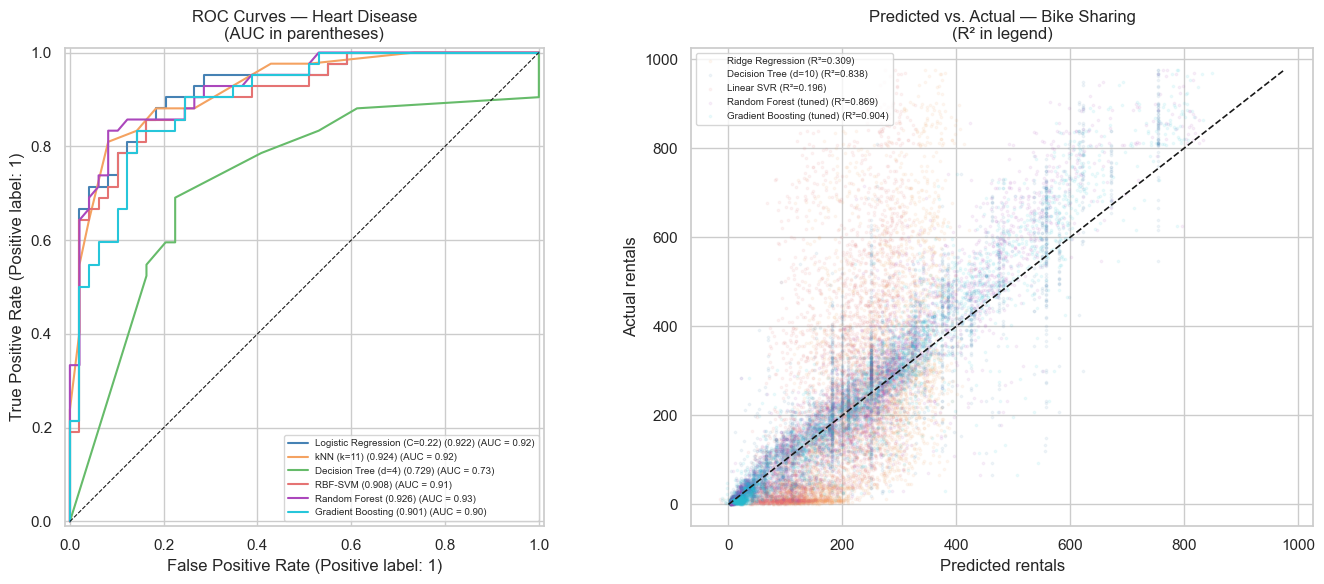

In [17]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Classification ROC ────────────────────────────────────────────────────
colors_cls = {
    "Logistic Regression (C=0.22)": "steelblue",
    "kNN (k=11)":                   "#F4A261",
    "Decision Tree (d=4)":          "#66BB6A",
    "RBF-SVM":                      "#E57373",
    "Random Forest":                "#AB47BC",
    "Gradient Boosting":            "#26C6DA",
}

for name, model in models_cls.items():
    y_proba = model.predict_proba(X_hte)[:, 1]
    RocCurveDisplay.from_predictions(
        y_hte, y_proba,
        name=f"{name} ({roc_auc_score(y_hte, y_proba):.3f})",
        ax=axes[0], color=colors_cls[name]
    )

axes[0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[0].set_title("ROC Curves — Heart Disease\n(AUC in parentheses)")
axes[0].legend(fontsize=7, loc="lower right")

# ── Regression: Predicted vs. Actual ────────────────────────────────────
colors_reg = ["gray", "#F4A261", "steelblue", "#E57373", "#AB47BC", "#26C6DA"]
model_names_reg = list(models_reg.keys())[1:]   # skip baseline

for name, model, color in zip(model_names_reg,
                               list(models_reg.values())[1:],
                               colors_reg[1:]):
    y_pred = model.predict(X_bte)
    r2 = r2_score(y_bte, y_pred)
    axes[1].scatter(y_pred, y_bte.values,
                    alpha=0.07, s=3, color=color,
                    label=f"{name} (R²={r2:.3f})")

lims = [0, y_bte.max()]
axes[1].plot(lims, lims, "k--", lw=1.2)
axes[1].set_title("Predicted vs. Actual — Bike Sharing\n(R² in legend)")
axes[1].set_xlabel("Predicted rentals")
axes[1].set_ylabel("Actual rentals")
axes[1].legend(fontsize=7, loc="upper left")

plt.tight_layout()
plt.savefig(FIGURES / "ch13_final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()